# 전체 과정
# [데이터 준비] -> [딥러닝 빌드] -> [서비스 구현]

STEP 1: 데이터 전처리 (Data Preprocessing)
딥러닝 모델이 텍스트를 이해할 수 있도록 '요리'하는 과정입니다.

1. 데이터 로드: Pandas로 리뷰 데이터를 불러오고 중복/결측치 제거.
2. 데이터 정제: 정규 표현식을 사용해 한글과 공백만 남기고 특수문자 제거.
3. 토큰화(Tokenization): Okt 분석기로 문장을 단어 단위로 쪼개기.
4. 불용어 제거: '은, 는, 이, 가'처럼 의미 없는 단어들 걸러내기.
5. 정수 인코딩: 단어들을 컴퓨터가 인식하는 숫자로 변환.
6. 패딩(Padding): 짧은 문장과 긴 문장의 길이를 일정하게 맞추기.

STEP 2: LSTM 모델 설계 및 학습 (Model Building)
뇌를 만들고 학습시키는 과정입니다.

1. 단어 임베딩(Embedding): 숫자로 된 단어들을 의미 있는 벡터 공간에 배치.
2. LSTM 레이어 쌓기: 문장의 맥락을 파악하도록 순환 신경망 구조 설계.
3. 모델 컴파일: 손실 함수(Loss), 최적화 함수(Optimizer) 설정.
4. 모델 학습: 데이터를 밀어 넣어 학습시키고, 정확도(Accuracy) 확인.
5. 결과물 저장: 가장 성능이 좋은 모델(h5)과 토크나이저(pickle)를 파일로 저

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

In [8]:
# STEP 1: 데이터 전처리 (Data Preprocessing)
# 1. 데이터 로드: Pandas로 리뷰 데이터를 불러오고 중복/결측치 제거.

# 데이터 불러오기
# 데이터 셋 : Naver Sentiment Movie Corpus (NSMC)
train_data = pd.read_csv('https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt', sep='\t')   # 독립 변수
test_data = pd.read_csv('https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt', sep='\t')     # 종속 변수

# 잘 불러와졌는지 확인 (상위 5개 데이터)
print(f"훈련 데이터 개수: {len(train_data)}")     # 15만건
print(train_data.head())
print(f"테스트 데이터 개수: {len(test_data)}")    #  5만건
print(test_data.head())
# 데이터 항목 : id(고유번호), document(리뷰 텍스트), label(긍정 1, 부정 0)

훈련 데이터 개수: 150000
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
테스트 데이터 개수: 50000
        id                                           document  label
0  6270596                                                굳 ㅋ      1
1  9274899                               GDNTOPCLASSINTHECLUB      0
2  8544678             뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아      0
3  6825595                   지루하지는 않은데 완전 막장임... 돈주고 보기에는....      0
4  6723715  3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??      0


In [9]:
# 훈련 데이터 정보 확인
print(train_data.info()) # 훈련 데이터는 document 컬럼에 5개의 결측치가 존재함

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB
None


In [10]:
# 테스트 데이터 정보 확인
print(test_data.info()) # 테스트 데이터는 document 컬럼에 3개의 결측치가 존재함

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB
None


In [11]:
# 훈련 데이터 결측치 확인
train_null_data = train_data[train_data['document'].isnull()]
print(train_null_data)

             id document  label
25857   2172111      NaN      1
55737   6369843      NaN      1
110014  1034280      NaN      0
126782  5942978      NaN      0
140721  1034283      NaN      0


In [12]:
# 테스트 데이터 결측치 확인
test_null_data = test_data[test_data['document'].isnull()]
print(test_null_data)

            id document  label
5746    402110      NaN      1
7899   5026896      NaN      0
27097   511097      NaN      1


In [13]:
# document 컬럼에 결측치가 있는 행을 제거
train_data = train_data.dropna(subset=['document'])
test_data = test_data.dropna(subset=['document'])

# 잘 제거되었는지 확인 (0이 나와야 함)
print(f"훈련 데이터 결측치 개수: {train_data['document'].isnull().sum()}")
print(f"테스트 데이터 결측치 개수: {test_data['document'].isnull().sum()}")

# 총 데이터의 개수
print(f"훈련 데이터 개수: {len(train_data)}")
print(f"테스트 데이터 개수: {len(test_data)}")

훈련 데이터 결측치 개수: 0
테스트 데이터 결측치 개수: 0
훈련 데이터 개수: 149995
테스트 데이터 개수: 49997


In [14]:
# document 컬럼을 기준으로 중복 데이터 제거
train_data.drop_duplicates(subset=['document'], inplace=True)
print(f"중복 제거 후 훈련 데이터 개수: {len(train_data)}")

중복 제거 후 훈련 데이터 개수: 146182


In [15]:
# 2. 데이터 정제: 정규 표현식을 사용해 한글과 공백만 남기고 특수문자 제거.
# 한글과 공백을 제외하고 모두 제거 (정규 표현식 활용)
# [^ㄱ-ㅎㅏ-ㅣ가-힣 ] -> 한글과 공백이 아닌 것들을 찾아서 공백('')으로 바꿈
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

# 잘 바뀌었는지 확인 (특수문자가 사라졌는지 보세요)
print(train_data[:5]) # 5번째 행 이전까지 슬라이싱한다는 점에서 train_data.head()와 동일

         id                                           document  label
0   9976970                                  아 더빙 진짜 짜증나네요 목소리      0
1   3819312                         흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                          교도소 이야기구먼 솔직히 재미는 없다평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...      1


In [16]:
# 토큰화(Tokenization) 및 불용어 제거(Stopwords Removal)
from konlpy.tag import Okt

# 1. 형태소 분석기 객체 생성
okt = Okt()

# 2. 불용어 리스트 정의 (감성 분석에 도움이 안 되는 단어들)
# 분석을 해보면서 나중에 여기에 단어를 추가하면 정확도가 올라갑니다!
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다','영화','최고','정말','진짜']

# 3. 테스트 (한 번 쪼개볼까요?)
print(okt.morphs("이 영화 진짜 재밌는데 왜 다들 욕하지?", stem=True))

# 훈련 데이터 토큰화 (리스트 형식으로 저장)
X_train = []
for sentence in train_data['document']:
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_train.append(stopwords_removed_sentence)

# 상위 3개만 확인
print(X_train[:3])

# (위의 X_train 코드 아래에 이어서 붙이세요)

# 테스트 데이터도 똑같이 토큰화 진행
X_test = []
for sentence in test_data['document']:
    tokenized_sentence = okt.morphs(sentence, stem=True)
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_test.append(stopwords_removed_sentence)

print("전체 데이터 토큰화 완료!")

['이', '영화', '진짜', '재밌다', '왜', '다', '들다', '욕', '하다', '?']
[['아', '더빙', '짜증나다', '목소리'], ['흠', '포스터', '보고', '초딩', '줄', '오버', '연기', '조차', '가볍다', '않다'], ['너', '무재', '밓었', '다그', '래서', '보다', '추천', '다']]
전체 데이터 토큰화 완료!


In [17]:
# 정수 인코딩(Integer Encoding)
# 1. 단어 집합(Vocabulary) 만들기 
# 훈련 데이터를 기반으로 어떤 단어에 몇 번 번호를 줄지 결정합니다.
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# 2. 텍스트를 정수 인덱스로 변환
# 예: ['영화', '재밌다'] -> [15, 203]
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

# 3. 결과 확인
print(X_train[:3])

[[46, 450, 256, 655], [929, 453, 37, 598, 210, 1445, 21, 957, 671, 16], [382, 2440, 25011, 2311, 5667, 1, 218, 8]]


In [18]:
# 1. 모든 리뷰의 길이를 동일하게 맞춤 (가장 긴 리뷰 기준 또는 일정 길이)
# 여기서는 가장 긴 리뷰의 길이를 확인하거나 보통 30~50 정도로 잡습니다.
max_len = 30 
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# 2. 결과 확인 (모든 데이터가 30개의 숫자로 채워졌는지 확인)
print(X_train.shape)
print(X_train[0])

(146182, 30)
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0  46 450 256 655]


In [19]:
# 훈련 데이터의 정답(0: 부정, 1: 긍정) 추출
y_train = np.array(train_data['label'])

# 테스트 데이터의 정답 추출
y_test = np.array(test_data['label'])

In [22]:
# [[***WARNING!!!***]]
# [[***학습 코드***]]
# [] 처음 학습 때만, 실행. 그 뒤론 오래걸리니 ***실행하지 말 것!!!***

# 1. 모델 설계
model = Sequential()
# 단어 집합의 크기를 대략 20,000으로 가정 (Tokenizer 설정에 따라 다를 수 있음)
model.add(Embedding(len(tokenizer.word_index) + 1, 100)) 
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid')) # 긍정/부정 이진 분류

# 2. 검증 데이터 손실이 증가하면 자동 중단하도록 설정
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

# 3. 모델 컴파일 및 학습 시작
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
# 학습 데이터 중 20%를 검증 데이터로 사용
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=60, validation_split=0.2)

Epoch 1/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.7560 - loss: 0.4863
Epoch 1: val_acc improved from None to 0.83148, saving model to best_model.h5


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 94s 47ms/step - acc: 0.8024 - loss: 0.4231 - val_acc: 0.8315 - val_loss: 0.3784
Epoch 2/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.8445 - loss: 0.3554
Epoch 2: val_acc improved from 0.83148 to 0.84044, saving model to best_model.h5


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 96s 49ms/step - acc: 0.8458 - loss: 0.3520 - val_acc: 0.8404 - val_loss: 0.3626
Epoch 3/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.8629 - loss: 0.3211
Epoch 3: val_acc improved from 0.84044 to 0.84424, saving model to best_model.h5


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 90s 46ms/step - acc: 0.8618 - loss: 0.3224 - val_acc: 0.8442 - val_loss: 0.3526
Epoch 4/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.8780 - loss: 0.2940
Epoch 4: val_acc did not improve from 0.84424
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 93s 48ms/step - acc: 0.8767 - loss: 0.2970 - val_acc: 0.8439 - val_loss: 0.3537
Epoch 5/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.8923 - loss: 0.2687
Epoch 5: val_acc improved from 0.84424 to 0.85200, saving model to best_model.h5


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 89s 46ms/step - acc: 0.8905 - loss: 0.2728 - val_acc: 0.8520 - val_loss: 0.3468
Epoch 6/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.9045 - loss: 0.2437
Epoch 6: val_acc did not improve from 0.85200
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 91s 46ms/step - acc: 0.9020 - loss: 0.2495 - val_acc: 0.8502 - val_loss: 0.3577
Epoch 7/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.9149 - loss: 0.2221
Epoch 7: val_acc did not improve from 0.85200
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 89s 45ms/step - acc: 0.9125 - loss: 0.2283 - val_acc: 0.8438 - val_loss: 0.3819
Epoch 8/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.9242 - loss: 0.2014
Epoch 8: val_acc did not improve from 0.85200
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 87s 45ms/step - acc: 0.9207 - loss: 0.2096 - val_acc: 0.8459 - val_loss: 0.3924
Epoch 9/15
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.9296 - loss: 0.1884
Epoch 9: val_acc did not improve from 0.85200
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 88s 4

In [20]:
loaded_model = load_model('best_model.h5')

# 테스트 데이터로 최종 정확도 측정
final_loss, final_acc = loaded_model.evaluate(X_test, y_test)

print(f"\n테스트 정확도: {final_acc * 100:.2f}%")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - acc: 0.8451 - loss: 0.3665

테스트 정확도: 84.51%


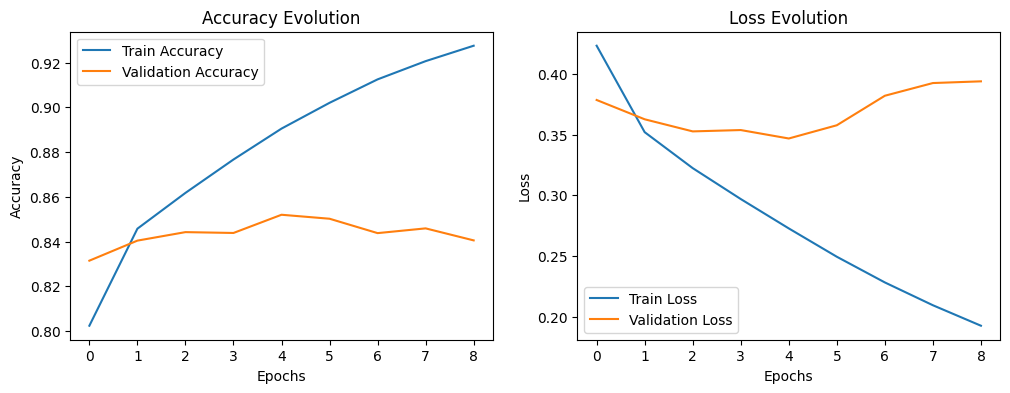

In [23]:
# 시각화

# 1. Accuracy(정확도) 그래프
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss(손실) 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [25]:
# 주피터 노트북 전용 코드 (한 번만 실행!)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("토크나이저 저장 완료!")

토크나이저 저장 완료!
